In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import pathlib
import gc
import warnings
warnings.filterwarnings('ignore')

ROOT = pathlib.Path().resolve()
DATA_FOLDER = ROOT / "data/bike"

print(DATA_FOLDER)

C:\Users\PatCa\Documents\PythonScripts\test_projects\big_data\bike_data\data\bike


In [2]:
df = pd.read_parquet(DATA_FOLDER / "pandas_full_2019.parquet")

In [3]:
df['day_of_year'] = df['starttime'].dt.dayofyear
df['start_day'] = df['starttime'].dt.day_name()
df['date'] = df['starttime'].dt.date
df['hour'] = df['starttime'].dt.hour
display(df.head(4))

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station longitude,end station latitude,bikeid,usertype,birth year,gender,day_of_year,start_day,date,hour
0,320,2019-01-01 00:01:47.401,2019-01-01 00:07:07.581,3160,Central Park West & W 76 St,40.778969,-73.973747,3283,W 89 St & Columbus Ave,40.788219,-73.970413,15839,Subscriber,1971,1,1,Tuesday,2019-01-01,0
1,316,2019-01-01 00:04:43.736,2019-01-01 00:10:00.608,519,Pershing Square North,40.751873,-73.977707,518,E 39 St & 2 Ave,40.747803,-73.973442,32723,Subscriber,1964,1,1,Tuesday,2019-01-01,0
2,591,2019-01-01 00:06:03.997,2019-01-01 00:15:55.438,3171,Amsterdam Ave & W 82 St,40.785248,-73.976677,3154,E 77 St & 3 Ave,40.773144,-73.958565,27451,Subscriber,1987,1,1,Tuesday,2019-01-01,0
3,2719,2019-01-01 00:07:03.545,2019-01-01 00:52:22.650,504,1 Ave & E 16 St,40.732220,-73.981659,3709,W 15 St & 6 Ave,40.738045,-73.996429,21579,Subscriber,1990,1,1,Tuesday,2019-01-01,0


In [4]:
trips_by_hour = df.groupby(['day_of_year','hour']).agg(
    date = pd.NamedAgg(column='date', aggfunc=lambda x: pd.Series.mode(x)[0]),
    count_trips = pd.NamedAgg(column='tripduration', aggfunc='count'),
    start_tripduration = pd.NamedAgg(column='tripduration', aggfunc='sum'),
    weekday = pd.NamedAgg(column='start_day', aggfunc=lambda x: pd.Series.mode(x)[0]),
    )
trips_by_hour['start_tripduration [hours]'] = round(trips_by_hour['start_tripduration']/60/60,2)
trips_by_hour['avg_tripduration [min]'] = round(trips_by_hour['start_tripduration [hours]']/trips_by_hour['count_trips']*60,2)

In [5]:
print(trips_by_hour.shape)
display(trips_by_hour.head(4))

(8759, 6)


date  count_trips  start_tripduration  weekday  \
day_of_year hour                                                         
1           0     2019-01-01          133              102522  Tuesday   
            1     2019-01-01          272              219922  Tuesday   
            2     2019-01-01          283              238141  Tuesday   
            3     2019-01-01          187              156793  Tuesday   

                  start_tripduration [hours]  avg_tripduration [min]  
day_of_year hour                                                      
1           0                          28.48                   12.85  
            1                          61.09                   13.48  
            2                          66.15                   14.02  
            3                          43.55                   13.97

In [6]:
df2 = trips_by_hour[['count_trips']].reset_index()
df2 = df2[['count_trips']].astype(np.float32)
display(df2.head(5))

,count_trips
0,133.0
1,272.0
2,283.0
3,187.0
4,120.0


In [7]:
#df1 = df.resample('60min', on='starttime').sum()
df1 = df.resample('60min', on='starttime').agg(func = None, 
    count_trips = pd.NamedAgg(column='tripduration', aggfunc='count'),
    start_tripduration = pd.NamedAgg(column='tripduration', aggfunc='sum')
)
display(df1.head(5))

,count_trips,start_tripduration
starttime,,
2019-01-01 00:00:00,133,102522
2019-01-01 01:00:00,272,219922
2019-01-01 02:00:00,283,238141
2019-01-01 03:00:00,187,156793
2019-01-01 04:00:00,120,87166


In [8]:
import gc
del df
gc.collect()

40

In [22]:
df1_sub = df1.loc['2019-06-17 00:00:00':'2019-06-30 23:00:00','count_trips'].to_frame()
print(type(df1_sub))
display(df1_sub)

<class 'pandas.core.frame.DataFrame'>


,count_trips
starttime,
2019-06-17 00:00:00,394
2019-06-17 01:00:00,212
2019-06-17 02:00:00,140
2019-06-17 03:00:00,83
2019-06-17 04:00:00,130
...,...
2019-06-30 19:00:00,4360
2019-06-30 20:00:00,3582
2019-06-30 21:00:00,2692


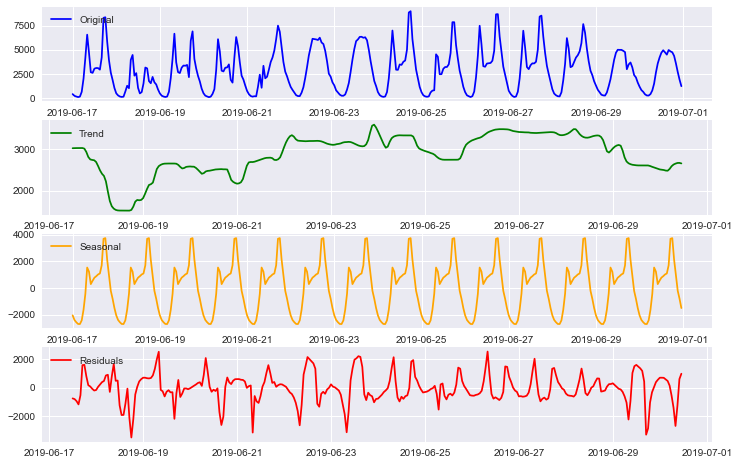

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose


decomposition = seasonal_decompose(df1_sub)

trend = decomposition.trend
seasonal = decomposition.seasonal
residuals = decomposition.resid

plt.figure(figsize=(12,8))
plt.subplot(411)
plt.plot(df1_sub,label='Original',color='blue')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend,label='Trend',color='green')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal,label='Seasonal',color='orange')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residuals,label='Residuals',color='red')
plt.legend(loc='upper left')

## Set up training, val and test datasets and overlapping datasets for lstm

In [10]:
# Make train test numpy arrays
# predict the last day

n_input = 48
n_output = 24

#%%
# For testing 1v to feed in 1v to predict
# For val 2w in, 1+1w to predict i.e. 3w
test_size = n_input+n_output+2
val_size = 3*n_input + n_output
train_size = val_size + test_size

train = df1.iloc[0:-(train_size),:] 
val = df1.iloc[-(test_size+val_size):-(test_size),:] 
test = df1.iloc[-(test_size):,:] 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler = scaler.fit(train[['count_trips']])
train['norm_count'] = scaler.transform(train[['count_trips']])
val['norm_count'] = scaler.transform(val[['count_trips']])
test['norm_count'] = scaler.transform(test[['count_trips']])

print(test_size)
print(train.shape, val.shape, test.shape)
print('total', train.shape[0] + val.shape[0] + test.shape[0])
display(test.head(5))

74
(8518, 3) (168, 3) (74, 3)
total 8760


,count_trips,start_tripduration,norm_count
starttime,,,
2019-12-28 22:00:00,685,569365,-0.792072
2019-12-28 23:00:00,556,496080,-0.852227
2019-12-29 00:00:00,485,340025,-0.885335
2019-12-29 01:00:00,278,221899,-0.981863
2019-12-29 02:00:00,184,134402,-1.025697


In [11]:
# %% Make input/output vectors [samples, timesteps, features] = [x, 48, 1]

def data_split(ds, time_step=48):
    data = []
    output = []
    end = 0
    
    for i in range(ds.shape[0]- time_step):
        start = i
        end = i + time_step

        data_temp = ds[start:end]
        out_temp = ds[start+time_step:end+time_step]
                
        # data_temp = ds[start:end,:].flatten()
        # out_temp = ds[start+time_step:end+time_step,:].flatten()
        
        data.append(data_temp)
        output.append(out_temp)

    data_ = np.asarray(data)
    output_ = np.asarray(output)
    
#    if ds.shape[1] > 1:      
#        return data_, output_     
#    else: return data_[...,np.newaxis], output_[...,np.newaxis]
    
    return data_, output_

# Single output step MLP model
# Input is numpy arrays output is X[samples, in_step], y[samples]
def seq_single_MLP(sequence, n_steps):
    X, y = [], []
    
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)


# Single output step LSTM model
# Input is numpy arrays output is X[samples, in_step], y[samples]
def seq_single_LSTM(sequence, n_steps):
    X, y = [], []
    
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    X = np.array(X)
    n_features = 1
    X = X.reshape((X.shape[0], X.shape[1], n_features))
        
    return X, np.array(y)
   
# Multi output step MLP model
# Input is numpy arrays output is X[samples, in_step], y[samples]
def seq_multi_MLP(sequence, n_input, n_output):
    X, y = [], []
    
    for i in range(len(sequence)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output
        if out_end_ix > len(sequence) - 1:
            break
        
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)
   
# Multi output step LSTM model
# Input is numpy arrays output is X[samples, in_step], y[samples]
def seq_multi_LSTM(sequence, n_input, n_output):
    X, y = [], []
    
    for i in range(len(sequence)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output
        if out_end_ix > len(sequence):
            break
        
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    X = np.array(X)
    n_features = 1
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, np.array(y)

# DOESNT WORK
# Multi output step CONVLSTM model
# Input is numpy arrays output is X[samples, in_step], y[samples]
def seq_multi_convLSTM(sequence, n_input, n_output):
    X, y = [], []
    
    for i in range(len(sequence)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output
        if out_end_ix > len(sequence):
            break
        
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    X = np.array(X)
    n_features = 1
    n_seq = 2
    n_steps = 2
    X = X.reshape((X.shape[0], n_seq, 1, n_steps, X.shape[1], n_features))
    return X, np.array(y)
    
# train_data, train_output = data_split(train.to_numpy().flatten(), n_input)
# val_data, val_output = data_split(val.to_numpy().flatten(), n_input)
# test_data, test_output = data_split(test.to_numpy().flatten(), n_input)


train_data, train_output = seq_multi_LSTM(train['norm_count'].to_numpy().flatten(), n_input, n_output)
val_data, val_output = seq_multi_LSTM(val['norm_count'].to_numpy().flatten(), n_input, n_output)
test_data, test_output = seq_multi_LSTM(test['norm_count'].to_numpy().flatten(), n_input, n_output)


print(train_data.shape, train_output.shape)
print(val_data.shape, val_output.shape)
print(test_data.shape, test_output.shape)


(8447, 48, 1) (8447, 24)
(97, 48, 1) (97, 24)
(3, 48, 1) (3, 24)


In [ ]:
print(type(test_data))
print(test_data, test_output)

# SARIMA

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

In [24]:
df1_sub['norm_count'] = scaler.transform(df1_sub[['count_trips']])


In [25]:
# --------------------- Dummy model ------------------------------------------------------
arima = ARIMA(df1_sub['norm_count'], order=(0,0,0), enforce_invertibility=False, enforce_stationarity=False)
results = arima.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             norm_count   No. Observations:                  336
Model:                          ARIMA   Log Likelihood                -483.208
Date:                Tue, 08 Nov 2022   AIC                            970.416
Time:                        23:20:07   BIC                            978.045
Sample:                    06-17-2019   HQIC                           973.458
                         - 06-30-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2328      0.063      3.699      0.000       0.109       0.356
sigma2         1.0481      0.102     10.307      0.000       0.849       1.247
===================================================================================
Ljung-Box (L1) (Q):                 247.89   Jarque-Bera (JB):                21.01
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.18   Skew:                             0.58
Prob(H) (two-sided):                  0.38   Kurtosis:                         2.61
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

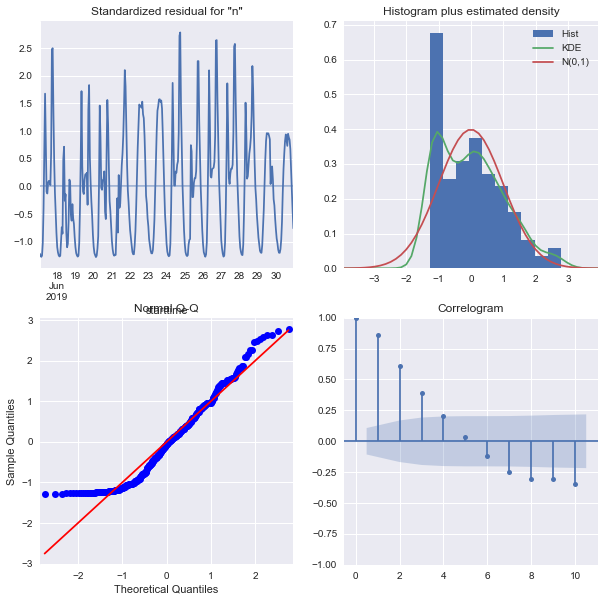

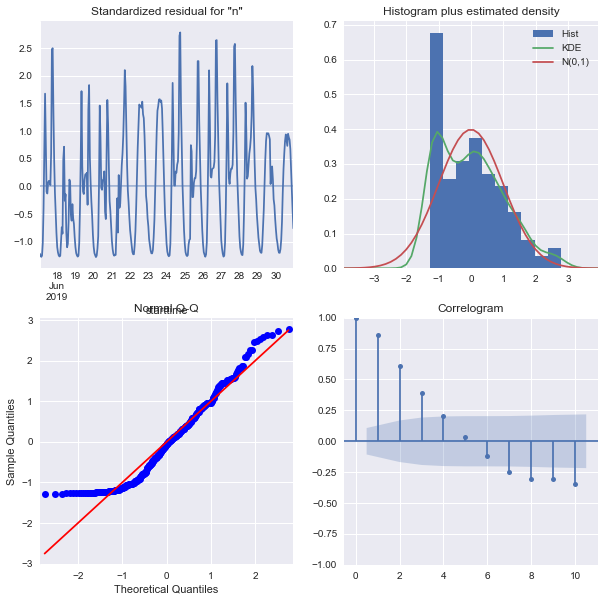

In [26]:
results.plot_diagnostics(figsize=(10,10))

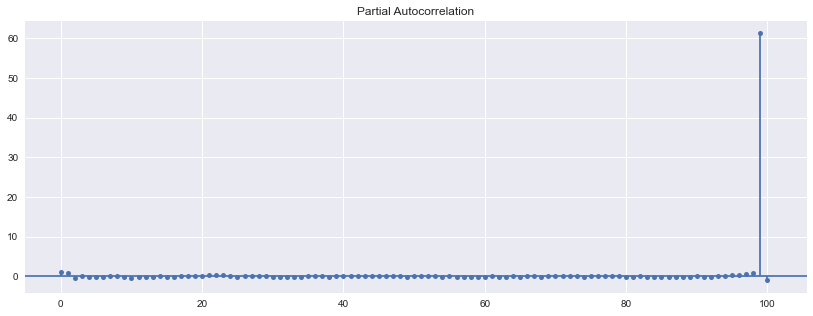

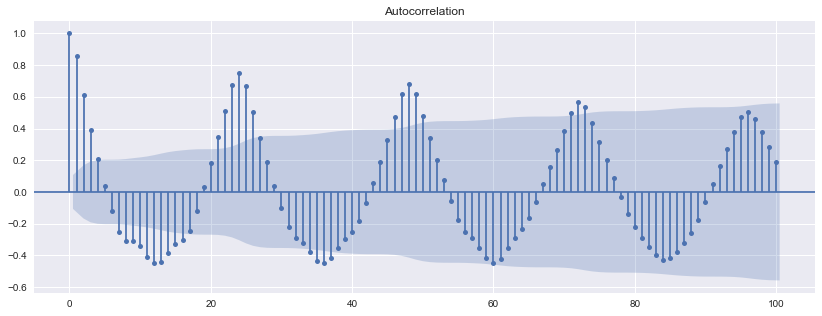

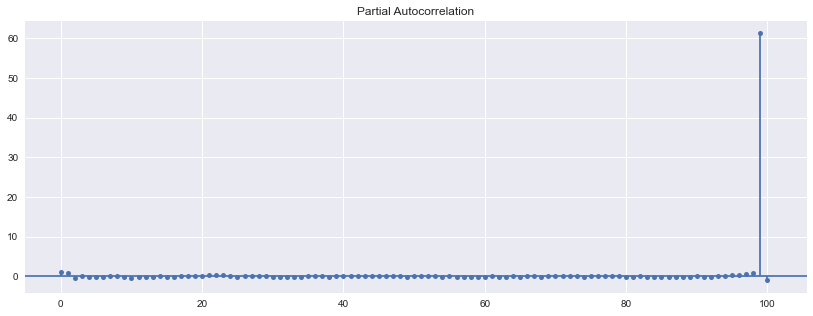

In [27]:
from matplotlib.pylab import rcParams
plt.style.use('seaborn')
rcParams['figure.figsize'] = 14,5
plot_acf(df1_sub['norm_count'], lags=100)
plot_pacf(df1_sub['norm_count'], lags=100)

In [29]:
import itertools
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARMA',
                        FutureWarning)
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARIMA',
                        FutureWarning)

np.random.seed(7)


#Generate combinations of the number of AR(p), MA(q), and Differencing (d) terms
p = d = q = range(0,2) #3)
pdq = list(itertools.product(p,d,q))

#Generate combinations of seasonal AR(p), MA(q), and Differencing (d) terms
pdqs = [(x[0], x[1], x[2], 24) for x in pdq] 
count = 1

##grid search parameters using generated list of combinations
models=[]
for comb in pdq:
    print(comb)
    for combs in pdqs:
        try:
            #try model
            arima = SARIMAX(df1_sub['norm_count'], order=comb, seasonal_order=combs,
                          enforce_invertibility=False,enforce_stationarity=False)
            model = arima.fit()
            arima.fit()
            
            #append results to list
            models.append([comb,combs,model.aic])
            count += 1
        except:
            continue #skip order combination if error

#create data frame of model performance from list and sort by best AIC values
models_df = pd.DataFrame(models, columns=['pdq', 'pdqs', 'aic'])
models_df.sort_values('aic').head(20)

[(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1), (1, 0, 0), (1, 0, 1), (1, 1, 0), (1, 1, 1)] [(0, 0, 0, 24), (0, 0, 1, 24), (0, 1, 0, 24), (0, 1, 1, 24), (1, 0, 0, 24), (1, 0, 1, 24), (1, 1, 0, 24), (1, 1, 1, 24)]
(0, 0, 0)
(0, 0, 1)
(0, 1, 0)
(0, 1, 1)
(1, 0, 0)
(1, 0, 1)
(1, 1, 0)
(1, 1, 1)


,pdq,pdqs,aic
43,"(1, 0, 1)","(0, 1, 1, 24)",223.149616
47,"(1, 0, 1)","(1, 1, 1, 24)",251.754344
35,"(1, 0, 0)","(0, 1, 1, 24)",256.399125
46,"(1, 0, 1)","(1, 1, 0, 24)",256.867086
45,"(1, 0, 1)","(1, 0, 1, 24)",265.045641
59,"(1, 1, 1)","(0, 1, 1, 24)",278.680863
39,"(1, 0, 0)","(1, 1, 1, 24)",279.905586
44,"(1, 0, 1)","(1, 0, 0, 24)",281.263441
27,"(0, 1, 1)","(0, 1, 1, 24)",281.267071
11,"(0, 0, 1)","(0, 1, 1, 24)",284.186193


In [30]:
best_sarima = SARIMAX(df1_sub['norm_count'], order=(1,0,1),seasonal_order=(0,1,1,24),
                    enforce_invertibility=False,enforce_stationarity=False)
results = best_sarima.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         norm_count   No. Observations:                  336
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 24)   Log Likelihood                -107.575
Date:                            Tue, 08 Nov 2022   AIC                            223.150
Time:                                    23:23:53   BIC                            237.774
Sample:                                06-17-2019   HQIC                           229.011
                                     - 06-30-2019                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5773      0.048     12.140      0.000       0.484       0.670
ma.L1          0.4387      0.052      8.504      0.000       0.338       0.540
ma.S.L24      -1.0000    162.736     -0.006      0.995    -319.956     317.956
sigma2         0.1056     17.178      0.006      0.995     -33.562      33.774
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               692.38
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.57   Skew:                            -0.88
Prob(H) (two-sided):                  0.01   Kurtosis:                        10.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

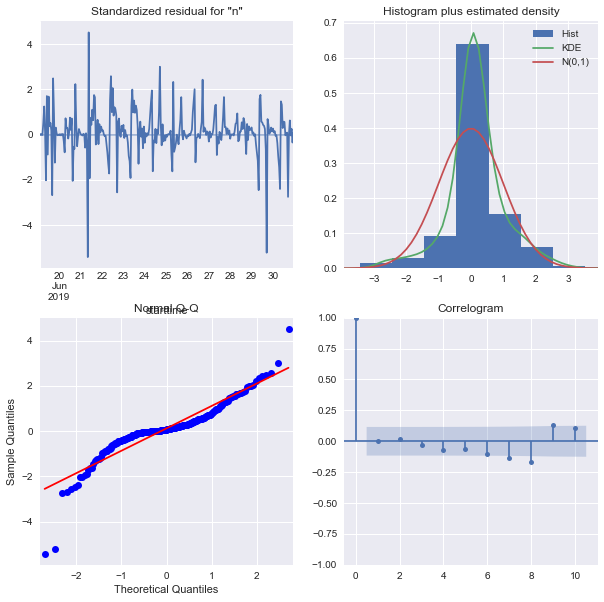

In [31]:
results.plot_diagnostics(figsize = (10,10))

In [32]:
best_sarima = SARIMAX(train['norm_count'], order=(1,0,1),seasonal_order=(0,1,1,24),
                    enforce_invertibility=False,enforce_stationarity=False)
results = best_sarima.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         norm_count   No. Observations:                 8518
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 24)   Log Likelihood                -843.418
Date:                            Tue, 08 Nov 2022   AIC                           1694.835
Time:                                    23:33:12   BIC                           1723.011
Sample:                                01-01-2019   HQIC                          1704.452
                                     - 12-21-2019                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6797      0.006    117.366      0.000       0.668       0.691
ma.L1          0.5821      0.008     73.961      0.000       0.567       0.598
ma.S.L24      -0.9415      0.002   -407.783      0.000      -0.946      -0.937
sigma2         0.0711      0.001    125.885      0.000       0.070       0.072
===================================================================================
Ljung-Box (L1) (Q):                  14.55   Jarque-Bera (JB):             11819.35
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.15   Skew:                            -0.38
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

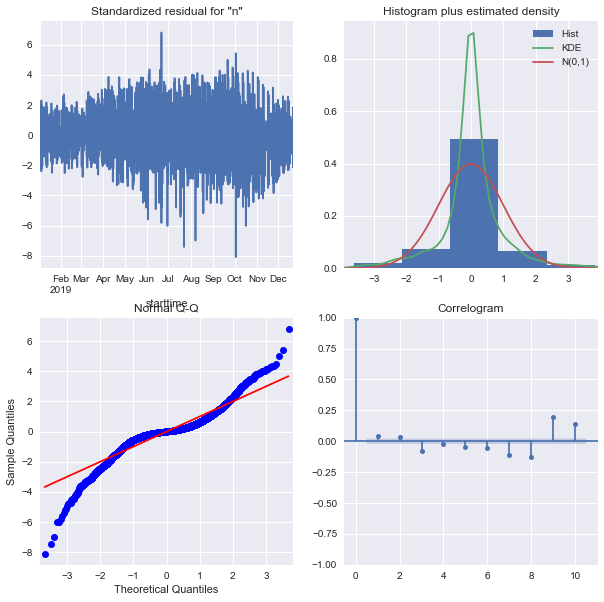

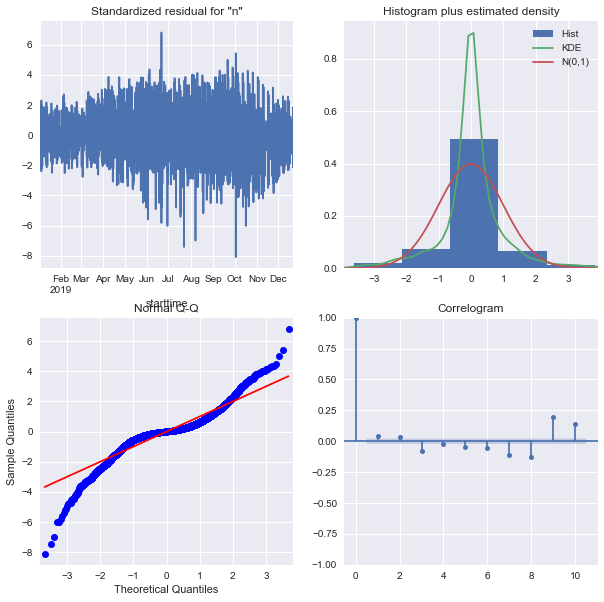

In [33]:
results.plot_diagnostics(figsize = (10,10))

# TF

In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Bidirectional, \
                        Conv1D, Flatten,MaxPooling1D, ConvLSTM2D, \
                        TimeDistributed, RepeatVector
from keras.optimizers import Adam

In [ ]:
def print_curves(history, train_met, test_met):
    plt.figure()
    plt.plot(history.history[train_met], label='train')
    plt.plot(history.history[test_met], label='test')
    plt.legend()
    plt.show()

In [ ]:
# %% ------------------- Test Univariate one step MLP models ----------------
# MLP
model = Sequential()
model.add(Dense(50, activation='relu', input_dim=n_input))
model.add(Dense(1,))

model.compile(optimizer=Adam(learning_rate=0.01), #'adam', 
              loss='mse', metrics='mae')

In [ ]:
# ------------- Simple fit function ------------------
model.fit(train_data,train_output, epochs=100, verbose=1)

In [ ]:
# ------------------- More advanced fit functiion ----------------------
from keras.callbacks import ModelCheckpoint,ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=5, min_lr=0.00001)

history = model.fit(train_data, train_output, 
                    validation_data=(val_data, val_output), 
                    epochs=300, verbose=1,
                    callbacks=[reduce_lr])
  
print_curves(history, 'loss', 'val_loss')
print_curves(history, 'mae', 'val_mae')

In [ ]:
#-------------------------- Basic single output LSTM -----------------------------------------------------

model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(train_data.shape[1], train_data.shape[2])))
#model.add(Dense(100, kernel_regularizer=tf.keras.regularizers.L1(0.01), 
#                activation='relu'))
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse', metrics='mae')

In [ ]:
history = model.fit(train_data, train_output, batch_size=128, epochs=30,
                    validation_data=(val_data, val_output), verbose=1)

print_curves(history, 'loss', 'val_loss')
#print_curves(history, 'mape', 'val_mape')
print_curves(history, 'mae', 'val_mae')

In [ ]:
#-------------------------- Basic multi step output LSTM -----------------------------------------------------

model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(train_data.shape[1], train_data.shape[2])))
model.add(LSTM(100, activation='relu'))
model.add(Dense(n_output))
model.compile(optimizer='adam', loss='mse', metrics='mae')

In [ ]:
history = model.fit(train_data, train_output, batch_size=128, epochs=30,
                    validation_data=(val_data, val_output), verbose=1)

print_curves(history, 'loss', 'val_loss')
#print_curves(history, 'mape', 'val_mape')
print_curves(history, 'mae', 'val_mae')

In [ ]:
y_pred = model.predict(test['norm_count'])


In [ ]:

plt.figure()
plt.plot(test_data.index, test_data)
plt.show()

In [ ]:
#------------------------ Conv Multi LSTM -------------------------------------------------
from keras.layers import TimeDistributed
from keras.layers.convolutional import Conv1D, MaxPooling1D

model = Sequential()
model.add(Conv1D(128,1,activation='relu', input_shape=(train_data.shape[1], train_data.shape[2])))
model.add(MaxPooling1D())
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(n_output))

model.compile(optimizer='adam', loss='mse', metrics='mae')

In [ ]:
history = model.fit(train_data, train_output, batch_size=128, epochs=1000,
                    validation_data=(val_data, val_output), verbose=1)

print_curves(history, 'loss', 'val_loss')
#print_curves(history, 'mape', 'val_mape')
print_curves(history, 'mae', 'val_mae')


In [ ]:
#------------------------ ConvLSTM Multi -------------------------------------------------
from keras.layers import ConvLSTM2D, Flatten
n_seq = 2

model = Sequential()
model.add(ConvLSTM2D(64,1,activation='relu', input_shape=(n_seq, 1, train_data.shape[1], train_data.shape[2])))
model.add(Flatten())
model.add(Dense(n_output))

model.compile(optimizer='adam', loss='mse', metrics='mae')

In [ ]:
history = model.fit(train_data, train_output, batch_size=128, epochs=1000,
                    validation_data=(val_data, val_output), verbose=1)

print_curves(history, 'loss', 'val_loss')
#print_curves(history, 'mape', 'val_mape')
print_curves(history, 'mae', 'val_mae')

In [ ]:
#------------------------ Conv Multi LSTM -------------------------------------------------
from keras.layers import TimeDistributed
from keras.layers.convolutional import Conv1D, MaxPooling1D

model = Sequential()
model.add(TimeDistributed(Conv1D(64,1,activation='relu'), input_shape=(None, train_data.shape[1], train_data.shape[2])))
model.add(TimeDistributed(MaxPooling1D()))
model.add(TimeDistributed(Flatten()))
model.add(LSTM(50, activation='relu'))
model.add(Dense(n_output))

model.compile(optimizer='adam', loss='mse', metrics='mae')